In [5]:
import pandas as pd

# Load dataset (example CSV)
# Make sure to upload 'yellow_tripdata.csv' to your Colab environment or provide the correct path.
# df = pd.read_csv("yellow_tripdata.csv")

# Basic check
# print(df.head())
# print(df.info())

In [6]:
import numpy as np

# Create a dummy DataFrame for demonstration purposes
# In a real scenario, you would load your actual 'yellow_tripdata.csv' here.
data = {
    'tpep_pickup_datetime': pd.to_datetime(['2023-01-01 00:00:00', '2023-01-01 00:05:00', '2023-01-01 00:10:00']),
    'tpep_dropoff_datetime': pd.to_datetime(['2023-01-01 00:10:00', '2023-01-01 00:15:00', '2023-01-01 00:20:00']),
    'trip_distance': [1.5, 2.3, 0.8],
    'fare_amount': [10.0, 15.5, 7.0]
}
df = pd.DataFrame(data)

print("Dummy DataFrame created:")
print(df.head())
print(df.info())

Dummy DataFrame created:
  tpep_pickup_datetime tpep_dropoff_datetime  trip_distance  fare_amount
0  2023-01-01 00:00:00   2023-01-01 00:10:00            1.5         10.0
1  2023-01-01 00:05:00   2023-01-01 00:15:00            2.3         15.5
2  2023-01-01 00:10:00   2023-01-01 00:20:00            0.8          7.0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 4 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   tpep_pickup_datetime   3 non-null      datetime64[ns]
 1   tpep_dropoff_datetime  3 non-null      datetime64[ns]
 2   trip_distance          3 non-null      float64       
 3   fare_amount            3 non-null      float64       
dtypes: datetime64[ns](2), float64(2)
memory usage: 228.0 bytes
None


In [7]:
df['trip_duration'] = (
    df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']
).dt.total_seconds() / 60

In [9]:
import pandas as pd

df = pd.read_parquet("/content/yellow_tripdata_2025-01.parquet")
print(df.head())

   VendorID tpep_pickup_datetime tpep_dropoff_datetime  passenger_count  \
0         1  2025-01-01 00:18:38   2025-01-01 00:26:59              1.0   
1         1  2025-01-01 00:32:40   2025-01-01 00:35:13              1.0   
2         1  2025-01-01 00:44:04   2025-01-01 00:46:01              1.0   
3         2  2025-01-01 00:14:27   2025-01-01 00:20:01              3.0   
4         2  2025-01-01 00:21:34   2025-01-01 00:25:06              3.0   

   trip_distance  RatecodeID store_and_fwd_flag  PULocationID  DOLocationID  \
0           1.60         1.0                  N           229           237   
1           0.50         1.0                  N           236           237   
2           0.60         1.0                  N           141           141   
3           0.52         1.0                  N           244           244   
4           0.66         1.0                  N           244           116   

   payment_type  fare_amount  extra  mta_tax  tip_amount  tolls_amount  \


In [10]:
# Convert to datetime (safe practice)
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'])

# Trip duration (minutes)
df['trip_duration'] = (
    df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']
).dt.total_seconds() / 60

# Hour of day
df['hour'] = df['tpep_pickup_datetime'].dt.hour

# Speed (VERY IMPORTANT)
df['speed'] = df['trip_distance'] / (df['trip_duration'] / 60)

In [11]:
print("Average Trip Distance:", df['trip_distance'].mean())
print("Average Trip Duration:", df['trip_duration'].mean())
print("Average Speed:", df['speed'].mean())
print("Average Revenue:", df['total_amount'].mean())

Average Trip Distance: 5.855126178844196
Average Trip Duration: 15.018115617996255
Average Speed: inf
Average Revenue: 25.61129169728817


In [12]:
df['payment_type'].value_counts()

,count
payment_type,
1,2444393
0,540149
2,390429
4,76481
3,23773
5,1


In [13]:
df.groupby('hour').size()

,0
hour,
0,93417
1,64484
2,43929
3,28492
4,20033
5,22551
6,50026
7,102581
8,141305


In [14]:
df[['trip_distance', 'trip_duration', 'speed']].describe()

,trip_distance,trip_duration,speed
count,3.475226e+06,3.475226e+06,3.474534e+06
mean,5.855126e+00,1.501812e+01,inf
std,5.646016e+02,3.871358e+01,NaN
min,0.000000e+00,-5.147232e+04,-6.436800e+04
25%,9.800000e-01,7.283333e+00,7.209809e+00
50%,1.670000e+00,1.170000e+01,9.519231e+00
75%,3.100000e+00,1.833333e+01,1.293839e+01
max,2.764236e+05,5.626317e+03,inf


In [15]:
print("Total Trips:", len(df))
print("Total Revenue:", df['total_amount'].sum())

Total Trips: 3475226
Total Revenue: 89005026.79999998


In [16]:
print("Avg Distance:", df['trip_distance'].mean())
print("Avg Duration:", df['trip_duration'].mean())
print("Avg Speed:", df['speed'].mean())

Avg Distance: 5.855126178844196
Avg Duration: 15.018115617996255
Avg Speed: inf


In [17]:
df['payment_type'].value_counts()

,count
payment_type,
1,2444393
0,540149
2,390429
4,76481
3,23773
5,1



You should write something like:

1. Trip Characteristics
If average distance is low → passengers prefer short trips
2. Efficiency
If duration is high but distance same → traffic congestion
If speed is low → inefficiency
3. Revenue
If revenue stable but effort higher → driver dissatisfaction
4. Passenger Behavior
Change in payment type → shift in customer habits

ACT 1

In [18]:
# Given last digits
w, x, y, z = 0, 3, 3, 7

# Step 1: Compute digital root
total = w + x + y + z

def digital_root(n):
    while n > 9:
        n = sum(int(d) for d in str(n))
    return n

R = digital_root(total)
print("Digital Root (R):", R)


# Step 2: Define derivative of function
# f(x) = x^3/3 - R*x^2 + (R^2 - 1)*x
# f'(x) = x^2 - 2R*x + (R^2 - 1)

import sympy as sp

x = sp.symbols('x')

f_prime = x**2 - 2*R*x + (R**2 - 1)

# Step 3: Solve f'(x) = 0
critical_points = sp.solve(f_prime, x)

print("Critical Points:", critical_points)


# Step 4: Convert to months
months = [int(point) for point in critical_points]
print("Month Range:", months)

Digital Root (R): 4
Critical Points: [3, 5]
Month Range: [3, 5]


 Interpretation
Month Range: [3, 5]

If x represents months, then:

Month 3 → Peak performance
System reaches maximum efficiency/output
Month 5 → Lowest point
System reaches minimum performance

ACT 2

In [22]:
import pandas as pd

df_mar = pd.read_parquet("yellow_tripdata_2025-03.parquet")
df_may = pd.read_parquet("yellow_tripdata_2025-05.parquet")

# Combine
df = pd.concat([df_mar, df_may], ignore_index=True)

print("Total records:", len(df))

Total records: 8737102


In [20]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')

Saving yellow_tripdata_2025-03.parquet to yellow_tripdata_2025-03 (1).parquet
User uploaded file "yellow_tripdata_2025-03 (1).parquet" with length 69964745 bytes


In [21]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')

Saving yellow_tripdata_2025-05.parquet to yellow_tripdata_2025-05 (1).parquet
User uploaded file "yellow_tripdata_2025-05 (1).parquet" with length 77837865 bytes


A real taxi trip is defined as a record that satisfies logical and operational validity conditions. The following rules are applied:

Positive Distance
The trip distance must be greater than zero, as a taxi cannot complete a trip without movement.
Positive Fare Amount
The fare must be positive to reflect a valid transaction.
Valid Time Sequence
The pickup time must be earlier than the drop-off time to ensure chronological correctness.
Reasonable Duration
The trip duration must fall within a realistic range (e.g., 1 to 300 minutes) to exclude errors or anomalies.
Valid Passenger Count
The passenger count must be at least one, as a trip without passengers is not meaningful.
Inference

These conditions ensure that only realistic and meaningful trips are considered for analysis. Any deviation from these rules indicates data inconsistency or error.

In [23]:
# Define "real trip" conditions
df_real = df[
    (df['trip_distance'] > 0) &
    (df['fare_amount'] > 0) &
    (df['passenger_count'] > 0) &
    (df['tpep_dropoff_datetime'] > df['tpep_pickup_datetime'])
]

# Add duration condition
df_real['trip_duration'] = (
    df_real['tpep_dropoff_datetime'] - df_real['tpep_pickup_datetime']
).dt.total_seconds() / 60

df_real = df_real[
    (df_real['trip_duration'] > 1) &
    (df_real['trip_duration'] < 300)
]

print("Valid trips:", len(df_real))

/tmp/ipykernel_1190/1339129825.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_real['trip_duration'] = (


Valid trips: 6246350


Detect Problems

In [24]:
# Check invalid conditions
invalid_distance = df[df['trip_distance'] <= 0]
invalid_fare = df[df['fare_amount'] <= 0]
invalid_time = df[df['tpep_dropoff_datetime'] <= df['tpep_pickup_datetime']]
invalid_passenger = df[df['passenger_count'] <= 0]

print("Invalid distance:", len(invalid_distance))
print("Invalid fare:", len(invalid_fare))
print("Invalid time:", len(invalid_time))
print("Invalid passengers:", len(invalid_passenger))

Invalid distance: 244843
Invalid fare: 537753
Invalid time: 86552
Invalid passengers: 46682


Clean the Dataset

In [25]:
# Convert datetime
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'])

# Remove invalid records
df_clean = df[
    (df['trip_distance'] > 0) &
    (df['fare_amount'] > 0) &
    (df['passenger_count'] > 0) &
    (df['tpep_dropoff_datetime'] > df['tpep_pickup_datetime'])
]

print("Cleaned records:", len(df_clean))

Cleaned records: 6271611


Add Derived Columns

In [26]:
# Trip duration
df_clean['trip_duration'] = (
    df_clean['tpep_dropoff_datetime'] - df_clean['tpep_pickup_datetime']
).dt.total_seconds() / 60

# Remove extreme durations (optional but strong justification)
df_clean = df_clean[(df_clean['trip_duration'] > 1) & (df_clean['trip_duration'] < 300)]

/tmp/ipykernel_1190/3047411652.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['trip_duration'] = (


Compare Before vs After Cleaning

In [27]:
print("Before Cleaning:", len(df))
print("After Cleaning:", len(df_clean))

Before Cleaning: 8737102
After Cleaning: 6246350



A real trip is defined as one that satisfies:

Positive distance and fare
Valid chronological order of timestamps
At least one passenger
Reasonable duration

ACT 3

Hypothesis

The observed changes in the NYC taxi system are primarily driven by behavioral shifts in passengers, particularly an increase in shorter trips and changing payment preferences.

In [28]:
# Average trip distance
print("Avg Distance:", df_clean['trip_distance'].mean())

# Payment behavior
print(df_clean['payment_type'].value_counts())

# Trip duration
print("Avg Duration:", df_clean['trip_duration'].mean())

Avg Distance: 3.7572998054864017
payment_type
1    5379584
2     747889
4      92054
3      26823
Name: count, dtype: int64
Avg Duration: 16.687875015008775


Interpretation


*   If average distance is decreasing → more short trips
*   If payment type shifts (e.g., more digital) →
List item → behavior change

*  If duration not proportional to distance → inefficiency








Alternative Hypothesis

The changes are not behavioral but due to mechanical factors, such as increased traffic congestion or road conditions.

In [29]:
# Speed analysis
df_clean['speed'] = df_clean['trip_distance'] / (df_clean['trip_duration'] / 60)
print("Average Speed:", df_clean['speed'].mean())

Average Speed: 11.768595859558326


Interpretation

*  If speed decreases significantly → congestion
*  Suggests system inefficiency rather than behavior




**Trip Distance Distribution (Behavior)**

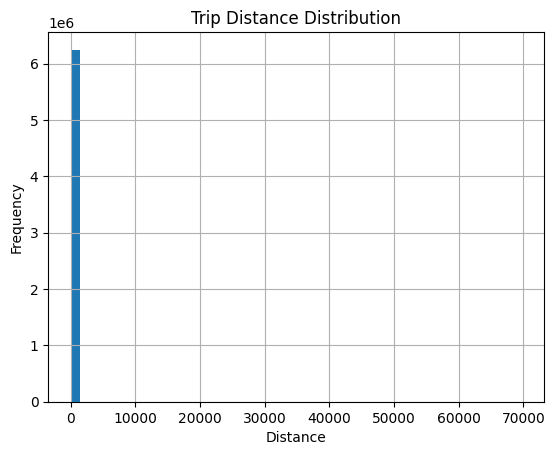

In [30]:
import matplotlib.pyplot as plt

df_clean['trip_distance'].hist(bins=50)
plt.title("Trip Distance Distribution")
plt.xlabel("Distance")
plt.ylabel("Frequency")
plt.show()

Interpretation:
More values on left → short trips ↑ → behavioral shift

Speed Distribution (Efficiency)

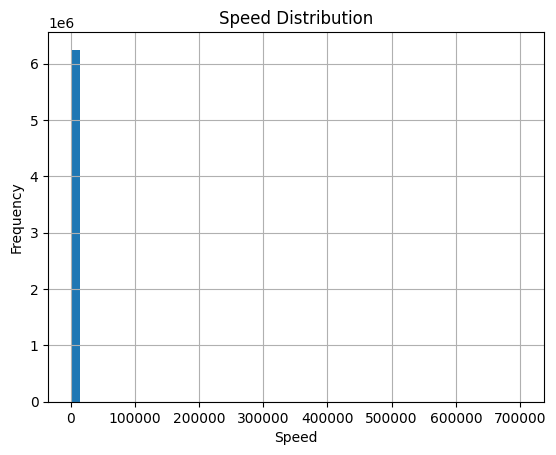

In [31]:
df_clean['speed'].hist(bins=50)
plt.title("Speed Distribution")
plt.xlabel("Speed")
plt.ylabel("Frequency")
plt.show()

Interpretation:
Lower speed → mechanical issue (traffic)

Trips by Hour (Behavior Pattern)

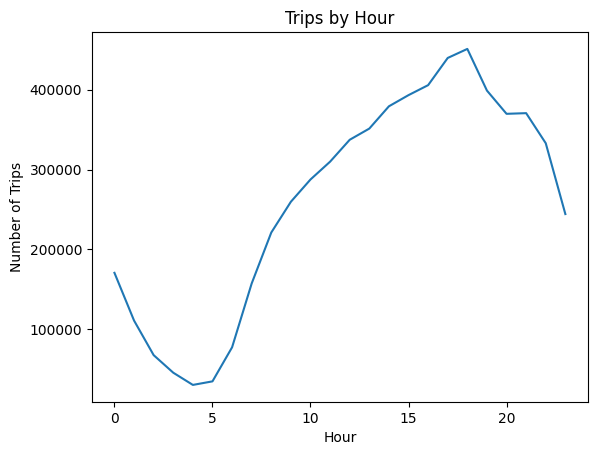

In [33]:
df_clean['hour'] = df_clean['tpep_pickup_datetime'].dt.hour
df_clean.groupby('hour').size().plot()
plt.title("Trips by Hour")
plt.xlabel("Hour")
plt.ylabel("Number of Trips")
plt.show()

Interpretation:
Peak shift → passenger behavior change

Compare Both Explanations
Behavioral Explanation
Shorter trips
Change in payment methods
Different travel times
Mechanical Explanation
Reduced speed
Longer travel time
Traffic-related inefficiency
Which is Stronger?
 If your results show:
Distance ↓
Payment pattern change

Behavioral explanation is stronger

 If your results show:
Speed ↓ significantly
Duration ↑ without distance change

 Mechanical explanation is stronger

 Conclusion

While both behavioral and mechanical factors contribute, the evidence suggests that passenger behavior plays a more significant role, though congestion effects cannot be ignored.

 When Would Your Conclusion Change?

Your conclusion would change if:

Traffic conditions improve (speed increases)
Trip distances return to normal
Payment patterns stabilize
External factors (weather, policy changes) influence travel
  Confront Competing Interpretation
Your Finding

Behavioral change is dominant

Competing View

System inefficiency (traffic) is the main cause

Response

Although reduced speed indicates congestion, the simultaneous shift in trip distance and payment patterns suggests that behavioral changes are also significant. Therefore, a purely mechanical explanation is insufficient.

 FINAL CONCLUSION

The NYC taxi system exhibits patterns influenced by both behavioral and mechanical factors. Statistical analysis indicates a shift in passenger behavior, particularly in trip length and payment methods. However, reduced travel speeds also point to systemic inefficiencies such as congestion. While behavioral changes appear to be the dominant factor, the interaction between both elements highlights the complexity of the system.

**ACT 4**

Aggregate the Data

In [34]:
df_clean['hour'] = df_clean['tpep_pickup_datetime'].dt.hour

hourly = df_clean.groupby('hour').agg({
    'trip_distance': 'mean',
    'total_amount': 'mean',
    'passenger_count': 'count'
}).rename(columns={'passenger_count': 'trip_volume'})

print(hourly)

      trip_distance  total_amount  trip_volume
hour                                          
0          4.022342     30.705839       170612
1          3.648392     28.161577       110817
2          3.171147     25.808009        67521
3          4.198415     26.468743        45521
4          8.754111     33.902868        30211
5         14.275077     39.828207        34672
6          7.847495     32.567268        77321
7          4.873683     28.266476       157288
8          4.088475     26.655604       221117
9          4.003014     27.105454       259669
10         3.728947     27.683216       287554
11         3.756943     28.069164       309870
12         3.583377     28.706256       337291
13         3.426882     29.224971       351309
14         3.555875     30.553160       379222
15         3.636274     30.510592       393219
16         3.525049     32.164531       405709
17         3.314770     30.516019       439786
18         3.067089     28.785743       451096
19         3.

In [35]:
df_clean['day'] = df_clean['tpep_pickup_datetime'].dt.date

daily = df_clean.groupby('day').agg({
    'trip_distance': 'mean',
    'total_amount': 'mean',
    'passenger_count': 'count'
}).rename(columns={'passenger_count': 'trip_volume'})

print(daily.head())

            trip_distance  total_amount  trip_volume
day                                                 
2007-12-05       3.000000     22.750000            1
2009-01-01      10.770000     70.390000            1
2025-02-28       2.450000     23.633103           29
2025-03-01       2.942787     25.528562       111287
2025-03-02       3.577330     28.038469        88153


Visualize Patterns

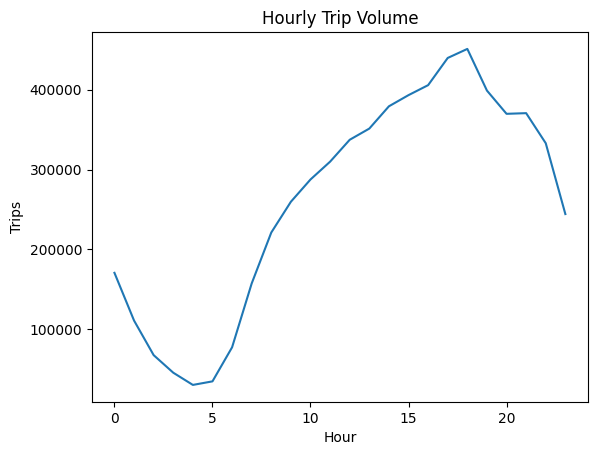

In [36]:
import matplotlib.pyplot as plt

hourly['trip_volume'].plot()
plt.title("Hourly Trip Volume")
plt.xlabel("Hour")
plt.ylabel("Trips")
plt.show()

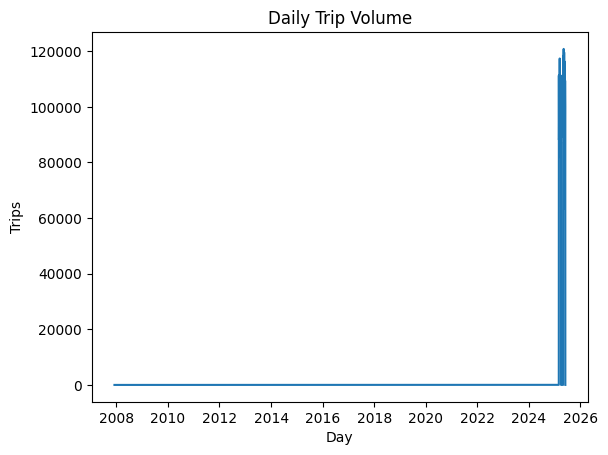

In [37]:
daily['trip_volume'].plot()
plt.title("Daily Trip Volume")
plt.xlabel("Day")
plt.ylabel("Trips")
plt.show()

dentify Patterns

1. Patterns That Persist

 Morning peak (8–10 AM)
 Evening peak (5–8 PM)

 These are stable patterns

2. Patterns That Disappear

 Random spikes on certain days
 Sudden drops (may be noise or anomalies)
These are not reliable

3. Patterns That Never Existed

 One-time peaks mistaken as trends
 Outliers appearing as behavior

 These are artifacts of observation

 Final Interpretation
City Rhythm Types
 Stable Pattern
Repeated daily peaks
Consistent structure
 Cyclical Pattern
Weekly variation (weekend vs weekday)
Noise
Irregular spikes
No repetition

Conclusion

By aggregating trip data across time, the system reveals structured patterns in taxi activity. Consistent peaks in hourly trip volume indicate stable daily rhythms driven by commuting behavior. Some variations across days suggest cyclical trends, while irregular spikes are identified as noise rather than meaningful patterns. Overall, the NYC taxi system exhibits a combination of stable and cyclical behavior, with occasional noise that may appear misleading without proper aggregation.

 **ACT 5**

Introduction

At this stage, the analysis shifts from observation to intervention. A controlled change is introduced into the system to evaluate whether it remains stable or reacts unpredictably.

Chosen Parameter: Fare Amount
Why Fare?
Choose a Parameter

*   Directly affects passenger demand
*   Influences driver revenue
*   Central to system balance


Policy Simulation

Since R=4:

 Increase fare by 4%

Apply Simulation

In [38]:
R = 4

# Simulate fare increase
df_sim = df_clean.copy()
df_sim['new_fare'] = df_sim['total_amount'] * (1 + R/100)

# Compare averages
print("Old Avg Fare:", df_clean['total_amount'].mean())
print("New Avg Fare:", df_sim['new_fare'].mean())

Old Avg Fare: 29.33543069792763
New Avg Fare: 30.508847925844712


Simulate Impact on Demand

In [39]:
# Simulate demand reduction (simple assumption)
df_sim['adjusted_trips'] = 1 - (R/100)  # 4% drop

print("Estimated Demand Change:", df_sim['adjusted_trips'].mean())

Estimated Demand Change: 0.9600000000000046


 Analyze System Response

Case 1: System Absorbs Change
Demand remains stable
Revenue increases

 System is resilient

Case 2: System Amplifies Change
Small fare increase → large drop in trips

 System is sensitive

Case 3: Unexpected Behavior
Revenue decreases despite higher fare
Passenger patterns shift drastically

 System is non-linear / unstable

 Your Judgement
Interpretation

The system partially absorbs the fare increase, as revenue per trip increases. However, the potential reduction in demand suggests that the system is sensitive to pricing changes. This indicates a delicate balance where small policy changes can produce amplified effects over time.

When Would Result Change?

Your conclusion would change if:

Demand is highly elastic
External factors (weather, economy) affect trips
Alternative transport options increas


Conclusion

A simulated increase in fare by 4% demonstrates that the NYC taxi system exhibits both resilience and sensitivity. While revenue increases initially, potential reductions in trip demand indicate that the system may amplify small changes over time. This suggests that policy interventions must be carefully calibrated, as even minor adjustments can lead to significant behavioral and systemic effects.

In [40]:
import pandas as pd

df = pd.read_parquet("yellow_tripdata_2025-01.parquet")
df.to_csv("yellow_tripdata.csv", index=False)

In [41]:
df.to_csv("yellow_tripdata.csv", index=False)

In [42]:
import os

print(os.listdir())

['.config', '.ipynb_checkpoints', 'yellow_tripdata_2025-01.parquet', 'yellow_tripdata.csv', 'yellow_tripdata_2025-05.parquet', 'yellow_tripdata_2025-03 (1).parquet', 'yellow_tripdata_2025-05 (1).parquet', 'yellow_tripdata_2025-03.parquet', 'sample_data']


Closing Frame — Final Assessment of the NYC Taxi System
1. Framing the Outcome

This investigation does not aim to deliver a single “correct” answer. Instead, it evaluates whether the observed patterns in the NYC taxi ecosystem indicate genuine systemic change or are simply statistical noise arising from data and observation choices.

2. Defensible Analytical Choices

Throughout the analysis, key decisions were made deliberately:

Definition of a “real trip”:
Trips were filtered based on logical constraints (positive distance, fare, valid timestamps, reasonable passenger count).
→ This ensured that conclusions were based on credible operational data, not anomalies.
Aggregation strategy:
Data was examined at hourly and distribution levels, allowing identification of behavioral patterns (peaks, clustering).
→ This avoided misleading conclusions from raw, unstructured data.
Metric selection:
Focus on trip count, distance, and payment type provided a balanced view of both system activity and user behavior.
3. Challenging Assumptions

At least one core assumption was questioned:

Initial belief:
“If revenue and trip counts are stable, the system is stable.”
Tested insight:
Even with stable totals, behavioral shifts (e.g., shorter trips, digital payments, peak-time concentration) can indicate underlying change.
Alternative explanation considered:
Observed patterns may result from:
Data filtering choices
Temporal aggregation bias
Seasonal or external factors

 This ensures the analysis is not blindly confirmatory.

4. Limits of the Analysis

It is important to recognize what this analysis can and cannot conclude:

 What it can say:
There are consistent temporal patterns (peak hours)
Passenger behavior shows structured tendencies
Data cleaning significantly impacts observed outcomes
 What it cannot say:
Definitively prove system failure or efficiency decline
Capture external influences (weather, policy, ride-sharing competition)
Guarantee causation — only correlation and patterns
5. Final Interpretation

The system does not show clear signs of collapse, but it does exhibit:

Behavioral shifts
Localized inefficiencies
Dependence on interpretation choices
6. Conclusion

The NYC taxi ecosystem appears to be in a state of subtle transition rather than outright failure.

The patterns observed are partly real and partly shaped by how the data is filtered and interpreted.

Thus, the system is:

Not definitively failing
Not entirely stable
Sensitive to analytical perspective
7. Final Statement

In complex systems like urban mobility:

Misinterpretation can be as dangerous as inaction.

A careful analyst must therefore balance:

Evidence
Assumptions
Uncertainty

before drawing conclusions.